In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hafeezabro/ushape/ushape.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/datasets/hafeezabro/ushape/ushape.csv')

In [4]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


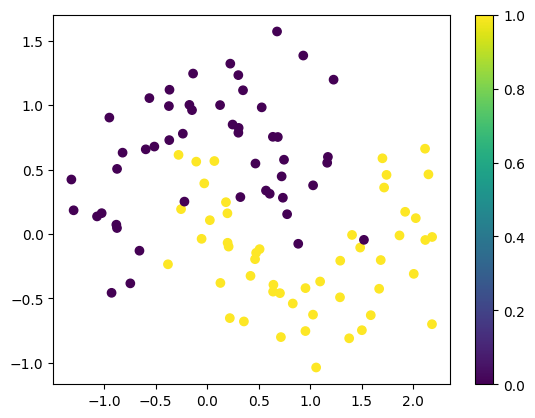

In [7]:
df.columns = ['X','Y','class']
plt.scatter(df['X'],df['Y'],c=df['class'])
plt.colorbar()
plt.show()

In [9]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [11]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [13]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-19 12:52:21.032942: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.get_weights()

[array([[-0.573769  ,  0.54961103, -0.13460845, -0.06034333,  0.6204491 ,
          0.07762289,  0.20815569, -0.2561704 ,  0.17422932,  0.42994457],
        [ 0.57877403, -0.11696374, -0.2527371 ,  0.5327504 ,  0.36194736,
          0.3782695 ,  0.30279607, -0.04199177,  0.23590416, -0.37710825]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.40230232, -0.4008079 ,  0.00900674, -0.44478655,  0.46834314,
         -0.01796412,  0.38348812,  0.35308492,  0.01654172, -0.48190922],
        [-0.02293009,  0.2082169 , -0.00912946,  0.12795287, -0.3470857 ,
         -0.46932754, -0.30964702,  0.1085555 ,  0.01310784, -0.40379468],
        [-0.32958418,  0.35389102, -0.16054082,  0.37863994, -0.16420746,
         -0.49839038, -0.4101557 , -0.43405032,  0.08829904, -0.33103904],
        [-0.5296702 , -0.16003439, -0.20053238, -0.15896371, -0.4874208 ,
         -0.31951082, -0.22854635,  0.21443611,  0.5217242 , -0.23513094],
        [-0.12972

In [16]:
initial_weights = model.get_weights()

In [20]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [21]:
model.set_weights(initial_weights)

In [22]:
model.get_weights()

[array([[ 1.6494625 ,  0.3121039 , -0.4182549 , -0.25314447, -0.6905844 ,
         -0.14083964, -0.3052268 , -0.16665329,  0.0189995 , -0.73007005],
        [ 0.4235374 ,  0.7235791 , -0.14015937, -1.0125207 ,  0.15741508,
         -1.1454782 , -0.61345756, -1.3224146 , -0.696472  ,  0.27654284]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.3351334 , -0.26612562, -0.4086234 , -0.8265293 ,  0.22452098,
         -0.15898567,  0.37699685,  0.16491228, -0.39696208, -0.5106723 ],
        [-0.20483992,  0.03346894,  0.09670461, -0.07785711,  0.05259888,
          0.25028887,  0.2907104 ,  0.22010192,  0.35710534, -0.10662758],
        [-0.4767552 ,  0.26917595,  0.01909259,  0.09082898, -0.20068981,
         -0.07419799,  0.24243537,  0.0319407 ,  0.20986158, -0.35895148],
        [ 0.08006427,  0.01905959,  0.00572931,  0.06281702, -0.37841162,
         -0.49276856, -0.25118968,  0.46768975, -0.05033397,  0.35636172],
        [ 0.15172

In [23]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [24]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.6031 - loss: 0.6779 - val_accuracy: 0.8000 - val_loss: 0.6163
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6070 - loss: 0.6652 - val_accuracy: 0.8000 - val_loss: 0.6059
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6407 - loss: 0.6517 - val_accuracy: 0.8500 - val_loss: 0.5954
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6407 - loss: 0.6426 - val_accuracy: 0.8000 - val_loss: 0.5853
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6383 - loss: 0.6346 - val_accuracy: 0.8000 - val_loss: 0.5755
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5938 - loss: 0.6358 - val_accuracy: 0.8000 - val_loss: 0.5662
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6840 - loss: 0.6240 - val_accuracy: 0.8500 - val_loss: 0.5565
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7216 - loss: 0.6050 - val_accuracy: 0.8500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 990us/step


<Axes: >

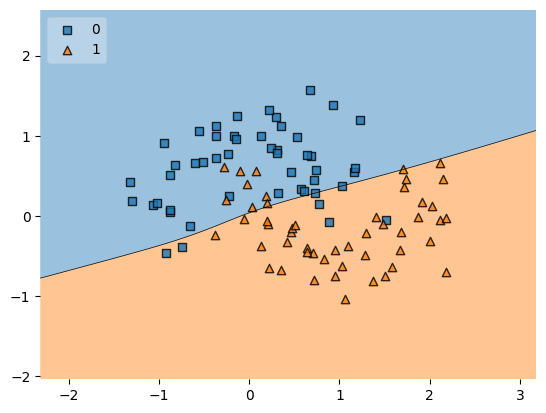

In [25]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf=model,legend=2)